In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('E:/data_analysis projects/diamonds.csv')

In [3]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df.shape

(53940, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [6]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [7]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [8]:
df['price']=df['price'].astype(float)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  float64
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 4.5+ MB


In [10]:
df[df.duplicated()]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z


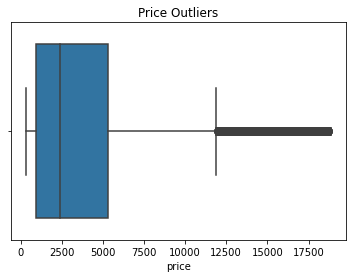

In [11]:
sns.boxplot(x=df['price']);
plt.title('Price Outliers');

# relationship between carat and dimensions (x, y, z)

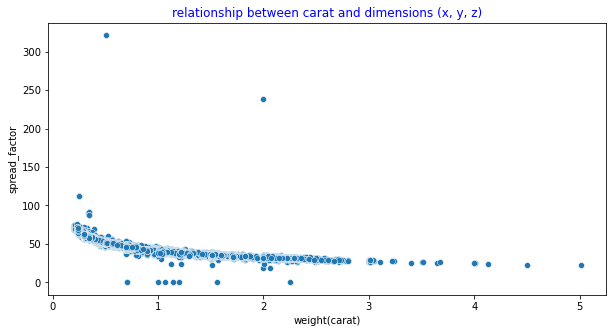

In [12]:
df['spread_factor'] = (df['x'] * df['y']) / df['carat'];
plt.figure(figsize=(10,5));
sns.scatterplot(x=df['carat'],y=df['spread_factor']);
plt.xlabel('weight(carat)');
plt.title('relationship between carat and dimensions (x, y, z)',color='b');

# Heatmap for Correlation Matrix

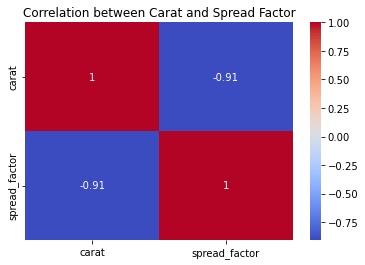

In [13]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['carat', 'spread_factor']].corr(), annot=True,cmap='coolwarm')
plt.title("Correlation between Carat and Spread Factor")
plt.show()

#Negative values → Inverse relationship.

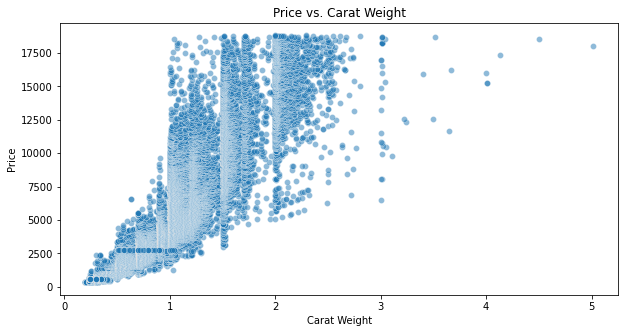

In [14]:
df['Price Per carat']=df['price']/df['carat']
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['carat'], y=df['price'], alpha=0.5)
plt.xlabel("Carat Weight")
plt.ylabel("Price")
plt.title("Price vs. Carat Weight")
plt.show()

# Evaluate how price per carat changes with increasing carat weight.

<AxesSubplot:>

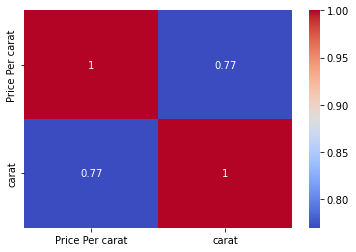

In [15]:
sns.heatmap(df[['Price Per carat', 'carat']].corr(),annot=True,cmap='coolwarm')
# 0.7 to 0.9 → Strong positive correlation

# Which cut is the most common?

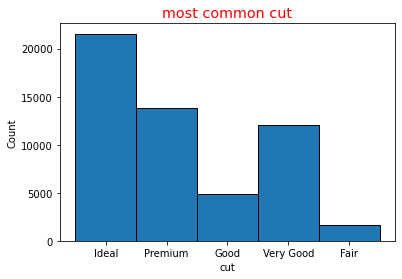

In [41]:
sns.histplot(data=df['cut'], palette='magma',alpha=1)
plt.title('most common cut',fontsize='x-large',color='r');


# Are "Ideal" cuts priced significantly higher than "Very Good"?

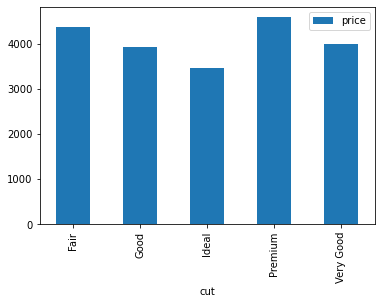

In [17]:
df[['cut','price']].groupby('cut').mean().plot(kind='bar');

# Does color significantly impact pricing?
 Are D-color diamonds priced much higher than J-color diamonds?

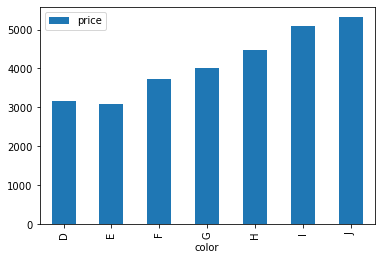

In [39]:
df[['color','price']].groupby('color').mean().plot(kind='bar');

# Best Color Choice?
G-H diamonds often offer a great balance between quality and price

In [19]:
high_quality = df[df['color'].isin(['D', 'E', 'F'])]['price'].mean()
mid_range = df[df['color'].isin(['H','G'])]['price'].mean()
low_quality  = df[df['color'].isin(['I', 'J'])]['price'].mean()

print(f"High-Quality (D-F) Avg Price: ${high_quality:.2f}")
print(f"Mid-Range (G-H) Avg Price: ${mid_range:.2f}")
print(f"Low-Quality (I-J) Avg Price: ${low_quality:.2f}")

High-Quality (D-F) Avg Price: $3337.76
Mid-Range (G-H) Avg Price: $4205.73
Low-Quality (I-J) Avg Price: $5171.01


# What Percentage of Diamonds Are IF (Internally Flawless)?

In [46]:
data = df.groupby('clarity')['clarity'].count()
c=data.loc['IF']
c*100/data.values.sum()

3.318502039302929

In [34]:
clarity_counts = df['clarity'].value_counts(normalize=True) * 100  ;
if_percentage = clarity_counts.get('IF', 0);
if_percentage


3.3185020393029294

# Are customers more likely to buy VS1 or VS2 instead of the most expensive IF?

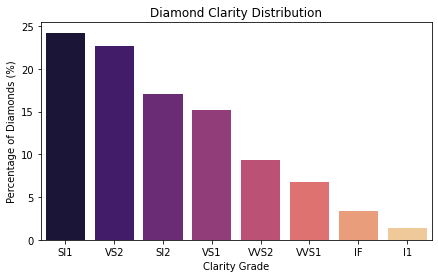

In [37]:
plt.figure(figsize=(7, 4))
sns.barplot(x=clarity_counts.index, y=clarity_counts.values, palette='magma')
plt.xlabel("Clarity Grade")
plt.ylabel("Percentage of Diamonds (%)")
plt.title("Diamond Clarity Distribution")
plt.show()